# Análisis Exploratorio de Datos #



## 1. Definición del Problema ##
Se analizará a continuación datos de los años 2024 y 2025 de las solicitudes de medicamentos de alto costo, dispositivos y actos médicos.
El obtetivo es saber es que caracteristicas tienen las solictudes aprobadas
Agregar más info, info básica del data set..

## Paso 2: Recopilación de datos

> Dataset de [FNR Solicitudes](https://www.fnr.gub.uy/estadisticas-2024/)

In [1]:
from email.quoprimime import header_encode
!python -m pip install -r ../requirements.txt


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# split para modelado
from sklearn.model_selection import train_test_split
# Scaled | Escalado
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# Encoding | Codificación
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
# To save models
import json
import pickle
# Feature Selection
from sklearn.feature_selection import f_classif, SelectKBest


In [3]:
!python -m pip list

Package                   Version
------------------------- ------------
altair                    6.2.2
anyio                     4.14.2
asttokens                 3.0.2
attrs                     26.1.0
blinker                   1.9.0
certifi                   2026.7.22
charset-normalizer        3.5.1
click                     8.4.2
colorama                  0.4.6
comm                      0.2.3
contourpy                 1.3.3
cycler                    0.12.1
debugpy                   1.8.21
executing                 2.2.1
fonttools                 4.63.0
h11                       0.16.0
httptools                 0.8.0
idna                      3.19
ipykernel                 7.3.0
ipython                   9.16.1
ipython_pygments_lexers   1.1.1
itsdangerous              2.2.0
jedi                      0.20.0
Jinja2                    3.1.6
joblib                    1.5.3
jsonschema                4.26.0
jsonschema-specifications 2025.9.1
jupyter_client            8.9.1
jupyter_core    

### Importamos los datos y creamos el DataFrame ###

In [4]:
df = pd.read_csv("../data/raw/FNR_solicitudes_2024_2025.csv", encoding="latin1")
df

,tipo_prestacion,area_prestacion,prestacion_cod,prestacion_desc,fecha_solicitud,estado_solcitud,fecha_autorización,pac_enmascarado,edad_años,sexo,departamento_residencia,prestador_salud,prestador_tipo,departamento_prestador,prestador_origen
0,Acto Médico,ACTOS CARDIOLOGÍA,201,Cateterismo diagnóstico infantil,7/28/2025,AUTORIZADO,8/8/2025,8236731,1,M,CANELONES,Hospital Policial,ASSE,CANELONES,PUBLICO
1,Acto Médico,ACTOS CARDIOLOGÍA,202,PCI-Cateterismo izq.adultos,5/7/2025,AUTORIZADO,5/8/2025,8119160,62,M,MONTEVIDEO,Hospital Español,ASSE,MONTEVIDEO,PUBLICO
2,Acto Médico,ACTOS CARDIOLOGÍA,202,PCI-Cateterismo izq.adultos,7/2/2025,AUTORIZADO,7/7/2025,8098843,71,F,MONTEVIDEO,Hospital Pasteur,ASSE,MONTEVIDEO,PUBLICO
3,Acto Médico,ACTOS CARDIOLOGÍA,302,PCI-ATCP c/cateterismo izq.,2/20/2025,AUTORIZADO,3/14/2025,8244840,56,M,ROCHA,Centro departamental de Rocha,ASSE,ROCHA,PUBLICO
4,Acto Médico,ACTOS CARDIOLOGÍA,302,PCI-ATCP c/cateterismo izq.,2/27/2025,AUTORIZADO,3/5/2025,8708606,79,F,RIO NEGRO,Centro departamental de Rio Negro,ASSE,RIO NEGRO,PUBLICO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71870,Acto Médico,ACTOS NEUROLOGÍA,2701,Neuromodulacion en enf. de Parkinson y Distoni...,03/06/2024,AUTORIZADO,20/06/2024,8216632,66,M,TACUAREMBO,COMTA IAMPP,IAMC,TACUAREMBO,PRIVADO
71871,Acto Médico,ACTOS NEUROLOGÍA,2701,Neuromodulacion en enf. de Parkinson y Distoni...,21/06/2024,AUTORIZADO,04/07/2024,8110928,68,F,CANELONES,CASMU,IAMC,MONTEVIDEO,PRIVADO
71872,Acto Médico,ACTOS NEUROLOGÍA,2701,Neuromodulacion en enf. de Parkinson y Distoni...,02/12/2024,AUTORIZADO,30/01/2025,8224793,42,M,LAVALLEJA,CAMDEL IAMPP,IAMC,LAVALLEJA,PRIVADO
71873,Acto Médico,ACTOS NEUROLOGÍA,2701,Neuromodulacion en enf. de Parkinson y Distoni...,29/10/2024,AUTORIZADO,05/12/2024,8219763,63,M,MONTEVIDEO,Hospital Maciel,ASSE,MONTEVIDEO,PUBLICO


In [5]:
    df.head()

,tipo_prestacion,area_prestacion,prestacion_cod,prestacion_desc,fecha_solicitud,estado_solcitud,fecha_autorización,pac_enmascarado,edad_años,sexo,departamento_residencia,prestador_salud,prestador_tipo,departamento_prestador,prestador_origen
0,Acto Médico,ACTOS CARDIOLOGÍA,201,Cateterismo diagnóstico infantil,7/28/2025,AUTORIZADO,8/8/2025,8236731,1,M,CANELONES,Hospital Policial,ASSE,CANELONES,PUBLICO
1,Acto Médico,ACTOS CARDIOLOGÍA,202,PCI-Cateterismo izq.adultos,5/7/2025,AUTORIZADO,5/8/2025,8119160,62,M,MONTEVIDEO,Hospital Español,ASSE,MONTEVIDEO,PUBLICO
2,Acto Médico,ACTOS CARDIOLOGÍA,202,PCI-Cateterismo izq.adultos,7/2/2025,AUTORIZADO,7/7/2025,8098843,71,F,MONTEVIDEO,Hospital Pasteur,ASSE,MONTEVIDEO,PUBLICO
3,Acto Médico,ACTOS CARDIOLOGÍA,302,PCI-ATCP c/cateterismo izq.,2/20/2025,AUTORIZADO,3/14/2025,8244840,56,M,ROCHA,Centro departamental de Rocha,ASSE,ROCHA,PUBLICO
4,Acto Médico,ACTOS CARDIOLOGÍA,302,PCI-ATCP c/cateterismo izq.,2/27/2025,AUTORIZADO,3/5/2025,8708606,79,F,RIO NEGRO,Centro departamental de Rio Negro,ASSE,RIO NEGRO,PUBLICO


## Paso 3:Análisis Descriptivo ##

Cantidad de filas y columnas del data set

In [6]:
df.shape

(71875, 15)

Obtenemos información sobre tipo de datos y valores nulos

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 71875 entries, 0 to 71874
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   tipo_prestacion          71875 non-null  str  
 1   area_prestacion          71875 non-null  str  
 2   prestacion_cod           71875 non-null  int64
 3   prestacion_desc          71875 non-null  str  
 4   fecha_solicitud          71875 non-null  str  
 5   estado_solcitud          71875 non-null  str  
 6   fecha_autorización       68691 non-null  str  
 7   pac_enmascarado          71875 non-null  int64
 8   edad_años                71875 non-null  int64
 9   sexo                     71875 non-null  str  
 10  departamento_residencia  71875 non-null  str  
 11  prestador_salud          71875 non-null  str  
 12  prestador_tipo           71875 non-null  str  
 13  departamento_prestador   71875 non-null  str  
 14  prestador_origen         71875 non-null  str  
dtypes: int64(3), 

Se observan 2 columnas de fecha que están como tipo de dato texto, se corrigen a tipo de dato fecha para poder analizar correctamente, ver de covertir a fecha

In [8]:
df[["fecha_solicitud", "fecha_autorización"]].head(20)

,fecha_solicitud,fecha_autorización
0,7/28/2025,8/8/2025
1,5/7/2025,5/8/2025
2,7/2/2025,7/7/2025
3,2/20/2025,3/14/2025
4,2/27/2025,3/5/2025
5,7/23/2025,7/24/2025
6,5/13/2025,5/22/2025
7,2/2/2025,2/6/2025
8,4/25/2025,5/27/2025
9,7/25/2025,7/25/2025


In [9]:
df[["fecha_solicitud", "fecha_autorización"]].dtypes

fecha_solicitud       str
fecha_autorización    str
dtype: object

Analizamos los formatos de ambas fechas

In [10]:
df.loc[
    df["fecha_solicitud"].str.contains("2024", na=False),
    ["fecha_solicitud", "fecha_autorización"]
].head(20)

,fecha_solicitud,fecha_autorización
36272,13/06/2024,NaN
36273,04/01/2024,11/01/2024
36274,19/01/2024,NaN
36275,31/01/2024,07/02/2024
36276,09/02/2024,16/02/2024
36277,15/02/2024,26/02/2024
36278,22/02/2024,05/03/2024
36279,22/02/2024,04/03/2024
36280,07/03/2024,28/06/2024
36281,18/03/2024,04/04/2024


Notamos que hay dos formatos de fechas, debemos ajustalos. Identificamos los formatos erroneos y luego ajustamos el formato.

In [28]:
mask_2024 = df["fecha_solicitud"].str.endswith("2024", na=False)
mask_2025 = df["fecha_solicitud"].str.endswith("2025", na=False)

In [29]:
    print("Registros 2024:", mask_2024.sum())
print("Registros 2025:", mask_2025.sum())
print("Total:", mask_2024.sum() + mask_2025.sum())
print("Filas del DataFrame:", len(df))

Registros 2024: 35596
Registros 2025: 36269
Total: 71865
Filas del DataFrame: 71865


Creamos una nueva columna con fechas correctas

In [31]:
    fecha_convertida = pd.Series(pd.NaT, index=df.index, dtype="datetime64[ns]")

Cargamos data 2024

In [32]:
fecha_convertida.loc[mask_2024] = pd.to_datetime(
    df.loc[mask_2024, "fecha_solicitud"],
    format="%d/%m/%Y"
)

Cargamos 2025

In [33]:
fecha_convertida.loc[mask_2025] = pd.to_datetime(
    df.loc[mask_2025, "fecha_solicitud"],
    format="%m/%d/%Y"
)

Sustituimos la columna erronea de dates por la correcta

In [34]:
df["fecha_solicitud"] = fecha_convertida

Chequeamos que este todo ok.

In [35]:
df["fecha_solicitud"].dtype

dtype('<M8[ns]')

In [36]:
df["fecha_solicitud"].head()

0   2025-07-28
1   2025-05-07
2   2025-07-02
3   2025-02-20
4   2025-02-27
Name: fecha_solicitud, dtype: datetime64[ns]

Resumen de las columnas numericas

In [37]:
df.isnull().sum()

tipo_prestacion               0
area_prestacion               0
prestacion_cod                0
prestacion_desc               0
fecha_solicitud               0
estado_solcitud               0
fecha_autorización         3180
edad_años                     0
sexo                          0
departamento_residencia       0
prestador_salud               0
prestador_tipo                0
departamento_prestador        0
prestador_origen              0
dtype: int64

In [38]:
df.describe()

,prestacion_cod,fecha_solicitud,edad_años
count,71865.000000,71865,71865.000000
mean,1558.388131,2024-12-30 03:56:41.026925568,63.493745
min,101.000000,2024-01-02 00:00:00,-32.000000
25%,302.000000,2024-06-28 00:00:00,56.000000
50%,1101.000000,2025-01-07 00:00:00,67.000000
75%,2102.000000,2025-06-30 00:00:00,75.000000
max,6007.000000,2025-12-31 00:00:00,104.000000
std,1735.888485,NaN,17.540181


Analizamos los outliers que existen en el campo años.

In [39]:
df["edad_años"].describe()

count    71865.000000
mean        63.493745
std         17.540181
min        -32.000000
25%         56.000000
50%         67.000000
75%         75.000000
max        104.000000
Name: edad_años, dtype: float64

Filtramos las celdas mas bajas

In [14]:
df.sort_values("edad_años")[["edad_años", "sexo", "departamento_residencia"]].head(10)

,edad_años,sexo,departamento_residencia
65263,-32,M,LAVALLEJA
21269,0,F,RIVERA
10623,0,M,ROCHA
32236,0,M,MONTEVIDEO
32237,0,F,SORIANO
32238,0,M,TREINTA Y TRES
57217,0,F,RIO NEGRO
21234,0,M,MONTEVIDEO
57622,0,M,CANELONES
57160,0,F,TACUAREMBO


Revisamos que no hayan mas casos menores a 0

In [40]:
df[df["edad_años"] < 0]

,tipo_prestacion,area_prestacion,prestacion_cod,prestacion_desc,fecha_solicitud,estado_solcitud,fecha_autorización,edad_años,sexo,departamento_residencia,prestador_salud,prestador_tipo,departamento_prestador,prestador_origen
65263,Otra Prestación,OTRA ÁREA,2102,Tomografía por emisión de positrones,2024-08-08,AUTORIZADO,17/02/2025,-32,M,LAVALLEJA,Seguro Americano,SEGURO PRIVADO,MONTEVIDEO,PRIVADO


El valor -32 es erroneo, vamos a sustituirlo por la media. Calculamos la media y lo sustituimos.

In [42]:
media_edad = df.loc[df["edad_años"] >= 0, "edad_años"].mean()

media_edad

np.float64(63.495074028720914)

In [44]:
media_edad = int(round(df.loc[df["edad_años"] >= 0, "edad_años"].mean()))

In [45]:
media_edad

63

In [46]:
df.loc[df["edad_años"] < 0, "edad_años"] = media_edad

In [47]:
df["edad_años"].min()

np.int64(0)

Analizo nuevamente los 10 mas bajos para confirmar que se modifico el valor negativo.

In [49]:
df.sort_values("edad_años")[["edad_años", "sexo", "departamento_residencia"]].head(10)

,edad_años,sexo,departamento_residencia
44,0,M,SAN JOSE
43,0,F,MONTEVIDEO
21267,0,F,CANELONES
21266,0,F,MONTEVIDEO
19,0,M,ROCHA
53,0,F,MONTEVIDEO
52,0,F,MONTEVIDEO
51,0,M,MONTEVIDEO
50,0,F,MALDONADO
35,0,F,CANELONES


Filtramos las celdas mas altas

In [17]:
df.sort_values("edad_años", ascending=False)[["edad_años", "sexo", "departamento_residencia"]].head(10)

,edad_años,sexo,departamento_residencia
8131,104,F,MONTEVIDEO
27947,102,F,MONTEVIDEO
55382,102,F,MONTEVIDEO
8380,102,F,MONTEVIDEO
26250,102,F,MONTEVIDEO
61977,101,F,MONTEVIDEO
5532,101,M,MONTEVIDEO
8278,101,M,MONTEVIDEO
42373,100,F,CANELONES
42536,100,M,MONTEVIDEO


In [18]:
df.duplicated().sum()

np.int64(10)

Reviso los registros duplicados:

In [19]:
df[df.duplicated(keep=False)]

,tipo_prestacion,area_prestacion,prestacion_cod,prestacion_desc,fecha_solicitud,estado_solcitud,fecha_autorización,pac_enmascarado,edad_años,sexo,departamento_residencia,prestador_salud,prestador_tipo,departamento_prestador,prestador_origen
11419,Otra Prestación,OTRA ÁREA,2102,Tomografía por emisión de positrones,3/10/2025,NO AUTORIZADO,NaN,8227565,52,F,CANELONES,CASMU,IAMC,MONTEVIDEO,PRIVADO
11420,Otra Prestación,OTRA ÁREA,2102,Tomografía por emisión de positrones,3/10/2025,NO AUTORIZADO,NaN,8227565,52,F,CANELONES,CASMU,IAMC,MONTEVIDEO,PRIVADO
11425,Otra Prestación,OTRA ÁREA,2102,Tomografía por emisión de positrones,3/10/2025,NO AUTORIZADO,NaN,8259443,81,M,MONTEVIDEO,COSEM,IAMC,MONTEVIDEO,PRIVADO
11426,Otra Prestación,OTRA ÁREA,2102,Tomografía por emisión de positrones,3/10/2025,NO AUTORIZADO,NaN,8259443,81,M,MONTEVIDEO,COSEM,IAMC,MONTEVIDEO,PRIVADO
32322,Acto Médico,ACTOS CARDIOLOGÍA,102,Cirugia cardiaca adultos,8/22/2025,NO AUTORIZADO,NaN,8260429,25,M,MONTEVIDEO,Hospital Maciel,ASSE,MONTEVIDEO,PUBLICO
32323,Acto Médico,ACTOS CARDIOLOGÍA,102,Cirugia cardiaca adultos,8/22/2025,NO AUTORIZADO,NaN,8260429,25,M,MONTEVIDEO,Hospital Maciel,ASSE,MONTEVIDEO,PUBLICO
48093,Otra Prestación,OTRA ÁREA,2102,Tomografía por emisión de positrones,02/05/2024,AUTORIZADO,18/09/2024,8159471,59,F,MONTEVIDEO,Asociacion Española,IAMC,MONTEVIDEO,PRIVADO
48094,Otra Prestación,OTRA ÁREA,2102,Tomografía por emisión de positrones,02/05/2024,AUTORIZADO,18/09/2024,8159471,59,F,MONTEVIDEO,Asociacion Española,IAMC,MONTEVIDEO,PRIVADO
48569,Otra Prestación,OTRA ÁREA,2102,Tomografía por emisión de positrones,12/06/2024,NO AUTORIZADO,NaN,7904501,79,M,CANELONES,Asociacion Española,IAMC,MONTEVIDEO,PRIVADO
48570,Otra Prestación,OTRA ÁREA,2102,Tomografía por emisión de positrones,12/06/2024,NO AUTORIZADO,NaN,7904501,79,M,CANELONES,Asociacion Española,IAMC,MONTEVIDEO,PRIVADO


Creo un nuevo DataFrame adicional para analizar duplicados sin la columna Pac_Enmascarado


In [20]:
df_sin_id = df.drop("pac_enmascarado", axis=1)

Analizo los duplicados en este nuevo Data Frame

In [21]:
df_sin_id.duplicated().sum()

np.int64(87)

Visualizo los nuevos duplicados

In [22]:
df_sin_id[df_sin_id.duplicated(keep=False)]

,tipo_prestacion,area_prestacion,prestacion_cod,prestacion_desc,fecha_solicitud,estado_solcitud,fecha_autorización,edad_años,sexo,departamento_residencia,prestador_salud,prestador_tipo,departamento_prestador,prestador_origen
1409,Acto Médico,ACTOS CARDIOLOGÍA,202,PCI-Cateterismo izq.adultos,2/24/2025,AUTORIZADO,3/5/2025,69,M,RIVERA,CASMER IAMPP,IAMC,RIVERA,PRIVADO
1410,Acto Médico,ACTOS CARDIOLOGÍA,202,PCI-Cateterismo izq.adultos,2/24/2025,AUTORIZADO,3/5/2025,69,M,RIVERA,CASMER IAMPP,IAMC,RIVERA,PRIVADO
1449,Acto Médico,ACTOS CARDIOLOGÍA,202,PCI-Cateterismo izq.adultos,2/27/2025,AUTORIZADO,3/6/2025,61,M,MONTEVIDEO,Asociacion Española,IAMC,MONTEVIDEO,PRIVADO
1451,Acto Médico,ACTOS CARDIOLOGÍA,202,PCI-Cateterismo izq.adultos,2/27/2025,AUTORIZADO,3/6/2025,61,M,MONTEVIDEO,Asociacion Española,IAMC,MONTEVIDEO,PRIVADO
5285,Acto Médico,ACTOS CARDIOLOGÍA,421,TAVI,6/3/2025,AUTORIZADO,6/6/2025,84,M,MONTEVIDEO,Asociacion Española,IAMC,MONTEVIDEO,PRIVADO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66199,Otra Prestación,OTRA ÁREA,2801,Cirugía fetal,27/08/2024,AUTORIZADO,01/10/2024,35,F,MONTEVIDEO,Asociacion Española,IAMC,MONTEVIDEO,PRIVADO
66204,Otra Prestación,OTRA ÁREA,2801,Cirugía fetal,20/12/2024,AUTORIZADO,11/03/2025,43,F,MONTEVIDEO,COSEM,IAMC,MONTEVIDEO,PRIVADO
66205,Otra Prestación,OTRA ÁREA,2801,Cirugía fetal,20/12/2024,AUTORIZADO,11/03/2025,43,F,MONTEVIDEO,COSEM,IAMC,MONTEVIDEO,PRIVADO
71149,Otra Prestación,OTRA ÁREA,2801,Cirugía fetal,03/12/2024,AUTORIZADO,18/12/2024,25,F,CERRO LARGO,Centro auxiliar de Rio Branco,ASSE,CERRO LARGO,PUBLICO


Se eliminan a continuación los duplicados de todas las columnas, incluyendo la columna pac_enmascarado, ya que no se tiene forma de verificar sea un error, y es valido que sean solicitudes en la que coincidan todos los datos, pero sean distintos pacientes.

In [23]:
df = df.drop_duplicates()

Verifico nuevamente los duplicados para asegurarme fueron eliminados

In [24]:
df.duplicated().sum()

np.int64(0)

### Limpieza de datos: Eliminar información irrelevante
 ¿Son todas las características imprescindibles para realizar una predicción?
 Se analiza la información y se concluye que la única columna que no aporta a la predicción es Pac_enmascarado.
 Antes de eliminarla se analiza cuantas solicitudes para el mismo paciente existen.

In [25]:
solicitudes_por_paciente = (
df.groupby('pac_enmascarado')
.size()
.reset_index(name='cantidad_solicitudes'))
solicitudes_por_paciente["cantidad_solicitudes"].describe()

count    57661.000000
mean         1.246336
std          0.542713
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          7.000000
Name: cantidad_solicitudes, dtype: float64

La distribución de solicitudes por paciente muestra una alta concentración en una única solicitud. El 75% de los pacientes registró una sola solicitud durante el período analizado.

Se procede a eliminar la columna pac_enmascarado

In [26]:
df.drop(["pac_enmascarado"],
        axis=1,
        inplace=True)
df

,tipo_prestacion,area_prestacion,prestacion_cod,prestacion_desc,fecha_solicitud,estado_solcitud,fecha_autorización,edad_años,sexo,departamento_residencia,prestador_salud,prestador_tipo,departamento_prestador,prestador_origen
0,Acto Médico,ACTOS CARDIOLOGÍA,201,Cateterismo diagnóstico infantil,7/28/2025,AUTORIZADO,8/8/2025,1,M,CANELONES,Hospital Policial,ASSE,CANELONES,PUBLICO
1,Acto Médico,ACTOS CARDIOLOGÍA,202,PCI-Cateterismo izq.adultos,5/7/2025,AUTORIZADO,5/8/2025,62,M,MONTEVIDEO,Hospital Español,ASSE,MONTEVIDEO,PUBLICO
2,Acto Médico,ACTOS CARDIOLOGÍA,202,PCI-Cateterismo izq.adultos,7/2/2025,AUTORIZADO,7/7/2025,71,F,MONTEVIDEO,Hospital Pasteur,ASSE,MONTEVIDEO,PUBLICO
3,Acto Médico,ACTOS CARDIOLOGÍA,302,PCI-ATCP c/cateterismo izq.,2/20/2025,AUTORIZADO,3/14/2025,56,M,ROCHA,Centro departamental de Rocha,ASSE,ROCHA,PUBLICO
4,Acto Médico,ACTOS CARDIOLOGÍA,302,PCI-ATCP c/cateterismo izq.,2/27/2025,AUTORIZADO,3/5/2025,79,F,RIO NEGRO,Centro departamental de Rio Negro,ASSE,RIO NEGRO,PUBLICO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71870,Acto Médico,ACTOS NEUROLOGÍA,2701,Neuromodulacion en enf. de Parkinson y Distoni...,03/06/2024,AUTORIZADO,20/06/2024,66,M,TACUAREMBO,COMTA IAMPP,IAMC,TACUAREMBO,PRIVADO
71871,Acto Médico,ACTOS NEUROLOGÍA,2701,Neuromodulacion en enf. de Parkinson y Distoni...,21/06/2024,AUTORIZADO,04/07/2024,68,F,CANELONES,CASMU,IAMC,MONTEVIDEO,PRIVADO
71872,Acto Médico,ACTOS NEUROLOGÍA,2701,Neuromodulacion en enf. de Parkinson y Distoni...,02/12/2024,AUTORIZADO,30/01/2025,42,M,LAVALLEJA,CAMDEL IAMPP,IAMC,LAVALLEJA,PRIVADO
71873,Acto Médico,ACTOS NEUROLOGÍA,2701,Neuromodulacion en enf. de Parkinson y Distoni...,29/10/2024,AUTORIZADO,05/12/2024,63,M,MONTEVIDEO,Hospital Maciel,ASSE,MONTEVIDEO,PUBLICO


## Paso 5: Análisis Variables ##

### Análisis de Variables Univariantes Categóricas

Las variables categóricas del data frame son las siguientes:


In [50]:
    df.select_dtypes(include=["object", "string"]).columns

Index(['tipo_prestacion', 'area_prestacion', 'prestacion_desc',
       'estado_solcitud', 'fecha_autorización', 'sexo',
       'departamento_residencia', 'prestador_salud', 'prestador_tipo',
       'departamento_prestador', 'prestador_origen'],
      dtype='str')

Ejemplo Histograma: variable categóricas

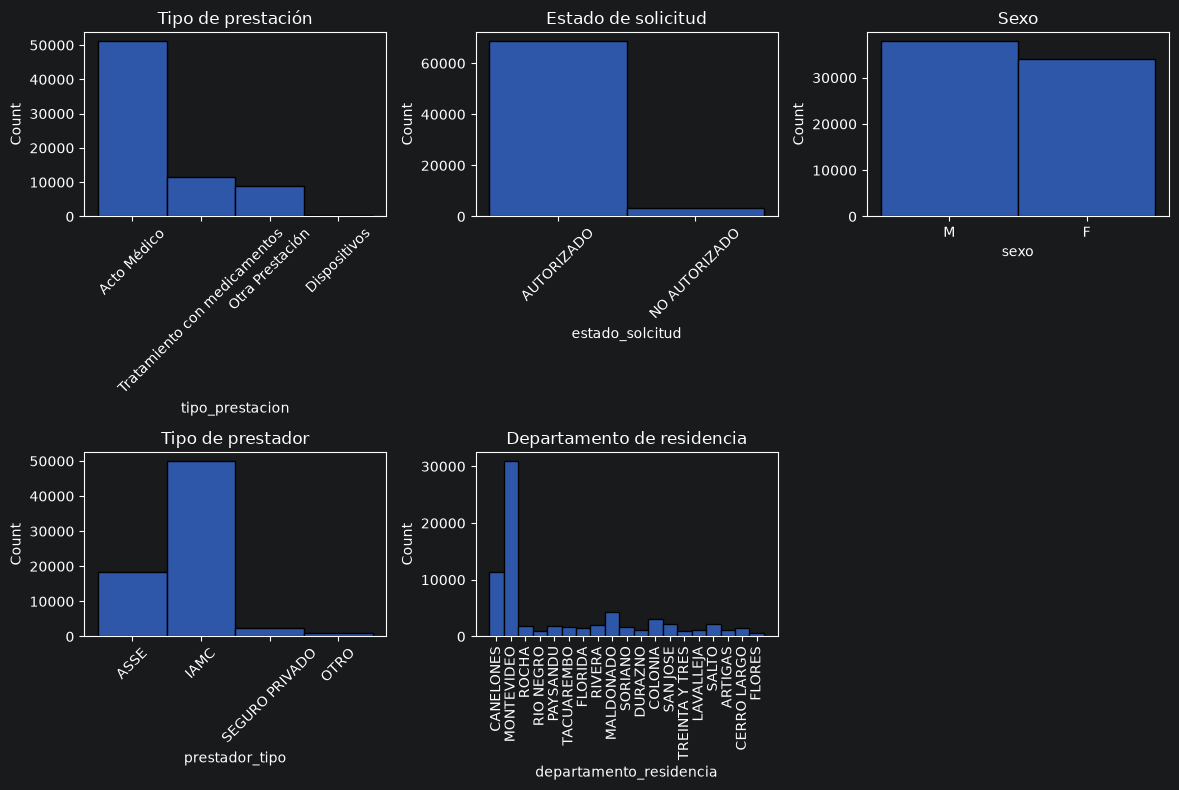

In [51]:
fig, axis = plt.subplots(2, 3, figsize=(12, 8))
sns.histplot(ax=axis[0, 0], data=df, x="tipo_prestacion")
axis[0, 0].set_title("Tipo de prestación")
axis[0, 0].tick_params(axis='x', rotation=45)
sns.histplot(ax=axis[0, 1], data=df, x="estado_solcitud")
axis[0, 1].set_title("Estado de solicitud")
axis[0, 1].tick_params(axis='x', rotation=45)
sns.histplot(ax=axis[0, 2], data=df, x="sexo")
axis[0, 2].set_title("Sexo")
sns.histplot(ax=axis[1, 0], data=df, x="prestador_tipo")
axis[1, 0].set_title("Tipo de prestador")
axis[1, 0].tick_params(axis='x', rotation=45)
sns.histplot(ax=axis[1, 1], data=df, x="departamento_residencia")
axis[1, 1].set_title("Departamento de residencia")
axis[1, 1].tick_params(axis='x', rotation=90)
plt.tight_layout()
axis[1, 2].set_visible(False)
plt.show()

### Observaciones

- Las solicitudes se concentran principalmente en **actos médicos**, que representan claramente el tipo de prestación más frecuente. Los tratamientos con medicamentos y otras prestaciones presentan una frecuencia considerablemente menor, mientras que los dispositivos representan una proporción muy reducida.

- La gran mayoría de las solicitudes del período analizado fueron **autorizadas**, mientras que las solicitudes no autorizadas representan una proporción mucho menor del total.

- La distribución de las solicitudes según **sexo** es relativamente equilibrada, aunque se observa una leve predominancia de pacientes de sexo masculino respecto a los de sexo femenino.

- En relación con el **tipo de prestador**, las IAMC (Instituciones de asistencia médica colectiva) concentran la mayor cantidad de solicitudes, seguidas por ASSE. Los prestadores privados y otros tipos de prestadores tienen una participación considerablemente menor.

- La distribución territorial muestra una marcada concentración de solicitudes correspondientes a pacientes residentes en **Montevideo**, seguido a distancia por los restantes departamentos.

#### Análisis de Variables Univariantes Numéricas

Existen 3 variables numericas en la base, edad y prestacion_cod. Prestacion_cod al ser un codigo no tiene sentido analizarla, vamos a centrarnos en edad.

In [52]:
df["edad_años"].describe()

count    71865.000000
mean        63.495067
std         17.536564
min          0.000000
25%         56.000000
50%         67.000000
75%         75.000000
max        104.000000
Name: edad_años, dtype: float64

In [53]:
media_edad = df["edad_años"].mean()
mediana_edad = df["edad_años"].median()
desvio_edad = df["edad_años"].std()
rango_edad = df["edad_años"].max() - df["edad_años"].min()

print("Media:", round(media_edad, 2))
print("Mediana:", mediana_edad)
print("Desviación estándar:", round(desvio_edad, 2))
print("Rango:", rango_edad)

Media: 63.5
Mediana: 67.0
Desviación estándar: 17.54
Rango: 104


generamos un histograma

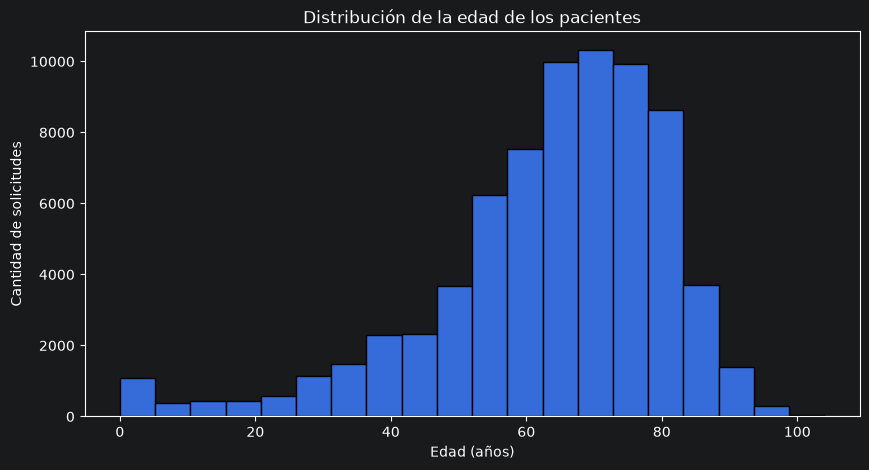

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    df["edad_años"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribución de la edad de los pacientes")
plt.xlabel("Edad (años)")
plt.ylabel("Cantidad de solicitudes")

plt.show()

In [57]:
df["edad_años"].quantile([0.25, 0.50, 0.75])


0.25    56.0
0.50    67.0
0.75    75.0
Name: edad_años, dtype: float64

Conclusiones Edad:

- La edad media de los pacientes es de 63,5 años, mientras que la mediana es de 67 años**.
- El 25 % de los registros corresponde a pacientes de hasta 56 años, mientras que el 75 % corresponde a pacientes de hasta 75 años.
- Por lo tanto, el 50 % central de los pacientes se encuentra entre los 56 y 75 años**.
- El histograma muestra una mayor concentración de solicitudes en edades medias y avanzadas, especialmente entre los 55 y 80 años.
- La mediana es superior a la media, lo que es consistente con la presencia de pacientes jóvenes que desplazan la media hacia valores menores.
- La desviación estándar es de 17,54 años, mostrando una dispersión considerable de las edades.
- El rango de edad es amplio, desde recien nacidos hasta alcanzar los 104 años.